# AI Programming Foundations Capstone Project 1

## SETUP

We need to install the libraries mentioned below either via the System Terminal or using the `!` symbol which allows us to run terminal commands directly from the Jupyter Notebook as done below. 

# Steps
1. Install libraries via PIP
2. Ensure that GIT is installed (if not, download [here](https://git-scm.com/install/))
3. Import the libraries

In [1]:
!pip install numpy pandas matplotlib seaborn scipy

In [2]:
!git --version

git version 2.50.1 (Apple Git-155)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## PYTHON OPTIONS

We will be doing a lot of visualizations, therefore its a good idea to set default values for accessibility reasons.
Also, we will save our installed PIP libraries from the Setup section in a TEXT file to replicate across environments via `pip install -r requirements.txt`. 

In [4]:
# Ignore all warnings
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(action='ignore', category=DeprecationWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x) 
sns.set(rc={'figure.figsize':(10,8)})
sns.set_style('white')

In [5]:
!pip freeze > requirements.txt

## LOAD DATASET

We use `PANDAS`, a powerful Python library that handles the dataframe access and operations, the base of our analysis. A CSV file is imported via `pd.read_csv()` function in a dataframe, and it is used for all of our usecases in this notebook. 

In [6]:
df = pd.read_csv("airbnb-data/AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## DATA ANALYSIS

This section analyzes the various statistical characterstics of the AIRBNB data, using the Pandas in-built functions, we can get a clear idea of the rows and columns in our datasets. 

In [7]:
def data_analysis(df):
    """
        Analyze the dataset properties using the PANDAS in-built functions
        Input:
            df: Pandas CSV dataframe
        Output:
            Report containing various data points
    """
    shape = df.shape
    columns = df.columns
    info = df.info()
    count = df.count()
    dtypes = df.dtypes
    return shape, columns, info, count, dtypes
    

In [8]:
def column_properties(df):
    """
        Analyze the columns properties using the PANDAS in-built functions
        Input:
            df: Pandas CSV dataframe
        Output:
            Report containing various data points
    """
    null_values_in_columns = df.isnull().sum(axis=0)
    df_description = df.describe()
    host_id_value_counts = df["host_id"].value_counts()
    minimum_nights_value_counts = df["minimum_nights"].value_counts()
    return null_values_in_columns, df_description, host_id_value_counts, minimum_nights_value_counts

In [9]:
print(data_analysis(df))

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [10]:
print(column_properties(df))

(id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64,                id      host_id  latitude  longitude    price  minimum_nights  \
count    48895.00     48895.00  48895.00   48895.00 48895.00        48895.00   
mean  19017143.24  67620010.65     40.73     -73.95   152.72            7.03   
std   10983108.39  78610967.03      0.05       0.05   240.15           20.51   
min       2539.00      24

In [11]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00,38843.00,48895.00,48895.00
mean,19017143.24,67620010.65,40.73,-73.95,152.72,7.03,23.27,1.37,7.14,112.78
std,10983108.39,78610967.03,0.05,0.05,240.15,20.51,44.55,1.68,32.95,131.62
min,2539.00,2438.00,40.50,-74.24,0.00,1.00,0.00,0.01,1.00,0.00
25%,9471945.00,7822033.00,40.69,-73.98,69.00,1.00,1.00,0.19,1.00,0.00
50%,19677284.00,30793816.00,40.72,-73.96,106.00,3.00,5.00,0.72,1.00,45.00
75%,29152178.50,107434423.00,40.76,-73.94,175.00,5.00,24.00,2.02,2.00,227.00
max,36487245.00,274321313.00,40.91,-73.71,10000.00,1250.00,629.00,58.50,327.00,365.00


Here are some observations from the output:

'price': The minimum price is 0, which seems strange, and the maximum price is 10,000, which is significantly higher than the 75th percentile. It also has high standard deviation.

'minimum_nights': The maximum value is 1,250, which is much higher than the 75th percentile.

'number_of_reviews': The maximum value is 629, which is much higher than the 75th percentile.

'reviews_per_month': The maximum value is 58.5, which is much higher than the 75th percentile.

'calculated_host_listings_count': The maximum value is 327, which is much higher than the 75th percentile.

# DATA CLEANING

Columns "name" and "host_name", "last_review" are irrelevant and insignificant to our data analysis
For "review_per_month" column we can simply append it with 0.0 for missing values

In [12]:
def drop_columns(df):
    """
        Clean up the dataframe by removing unnecessary columns
        Input:
            df: Pandas CSV dataframe
        Output:
            df: Pandas CSV dataframe with the required columns only present
    """
    df = df.drop(['id', 'name','host_name','last_review'], axis=1)   
    return df

In [13]:
def replace_NaNs(df):
    """
        Clean up the dataframe by removing null values
        Input:
            df: Pandas CSV dataframe
        Output:
            df: Pandas CSV dataframe without the NULL values
    """
    df.fillna({'reviews_per_month':0}, inplace=True)
    #examing the changes
    df.head(3)    
    return df

In [14]:
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365


We drop 'id', 'name' and 'host_name', 'last_review' not only because it is insignificant but also for ethical reasons (individual names are used).

1. Name and Host name doesn't have any numerical significance and only hinders our statistical calculations
2. Names and Host names are PII fields and hence need to be removed in a data analysis report
3. Name and Host names are strings of variable size, and significantly slow down any processing
4. ID is serial wise and doesn't make sense to keep with the dataframe already tracking rows
5. Last_review isn't necessary in our scope since we just check housing patterns not individual host rankings for example.

In [15]:
df = drop_columns(df)
df.head(3)

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,0.21,6,365
1,2845,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,0.38,2,355
2,4632,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,1,365


In [16]:
df = replace_NaNs(df)
df.head(3)

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,0.21,6,365
1,2845,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,0.38,2,355
2,4632,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,0.00,1,365


# DATA CLEANING: OUTLIERS

There are several ways to deal with outliers in a dataset:

Remove the outliers: Simply remove the rows containing outliers from the dataset. However, this can also lead to loss of information and affect the accuracy of the model. So, we should be careful while removing the outliers and make sure we have a valid reason for doing so.

Replace the outliers: We can replace the outliers with a value that makes more sense, for example, the mean, median, or mode of the data. This method can help preserve the data and still reduce the effect of outliers.

Transform the data: We can transform the data using techniques like log transformation, box-cox transformation, etc. This can help in reducing the effect of outliers and also improve the distribution of the data.

We can use Z-score method to remove outliers as below.

In [17]:
!pip install scipy

In [18]:
from scipy import stats

In [19]:

df_numeric = df.select_dtypes(include=[np.number])

for col in df_numeric.columns:
    # Calculate z-score of the column
    z_score = np.abs(stats.zscore(df[col]))
    outliers_num = len(np.where(z_score > 3)[0])
    if outliers_num:
        print('{}: {}'.format(col, outliers_num))

latitude: 99
longitude: 1236
price: 388
minimum_nights: 327
number_of_reviews: 1221
reviews_per_month: 847
calculated_host_listings_count: 680


In [20]:
z_scores = np.abs(stats.zscore(df_numeric))

# DataFrame without outliers
df_wo_outliers = df[(z_scores < 3).all(axis=1)]
df_wo_outliers.shape

(44475, 12)

In [21]:
df.shape

(48895, 12)

# EXPLORATORY DATA ANALYSIS

This section tries to find certain trends and patterns in the data, we try to find out the unique neighbourhood and room types. We also find out the top 10 hosts by number of listings to identify the distribution of hosts: a small group of hosts having the majority of the listings. 

In [22]:
def perform_EDA(df):
    """
        Perform EDA
        Input:
            df: Pandas CSV dataframe
        Output:
            EDA report
    """
    return df.neighbourhood_group.unique(), len(df.neighbourhood.unique()), df.room_type.unique(), len(df.room_type.unique())

In [23]:
perform_EDA(df)

(<StringArray>
 ['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
 Length: 5, dtype: str,
 221,
 <StringArray>
 ['Private room', 'Entire home/apt', 'Shared room']
 Length: 3, dtype: str,
 3)

In [24]:
top_10=df.host_id.value_counts().head(10)
top_10

host_id
219517861    327
107434423    232
30283594     121
137358866    103
16098958      96
12243051      96
61391963      91
22541573      87
200380610     65
1475015       52
Name: count, dtype: int64

In [25]:
top_10_hosts=pd.DataFrame(top_10)
top_10_hosts.reset_index(inplace=True)
top_10_hosts.rename(columns={'index':'Host_ID', 'host_id':'P_Count'}, inplace=True)
top_10_hosts

,P_Count,count
0,219517861,327
1,107434423,232
2,30283594,121
3,137358866,103
4,16098958,96
5,12243051,96
6,61391963,91
7,22541573,87
8,200380610,65
9,1475015,52


In [26]:
top_10_hosts.sum()

P_Count    808725914
count           1270
dtype: int64

# VISUALIZATION

Data Visualization using Matplotlib and Seaborn libraries. 
1. Hosts with most listings
2. Property types and counts for various neighbourhoods
3. Density and distribution of neighbourhoods
4. Distribution of Properties with price as gradient
5. Distribution of Properties with price as gradient mapped on NYC latitude and longitude

[Text(0, 0, '1475015'),
 Text(1, 0, '12243051'),
 Text(2, 0, '16098958'),
 Text(3, 0, '22541573'),
 Text(4, 0, '30283594'),
 Text(5, 0, '61391963'),
 Text(6, 0, '107434423'),
 Text(7, 0, '137358866'),
 Text(8, 0, '200380610'),
 Text(9, 0, '219517861')]

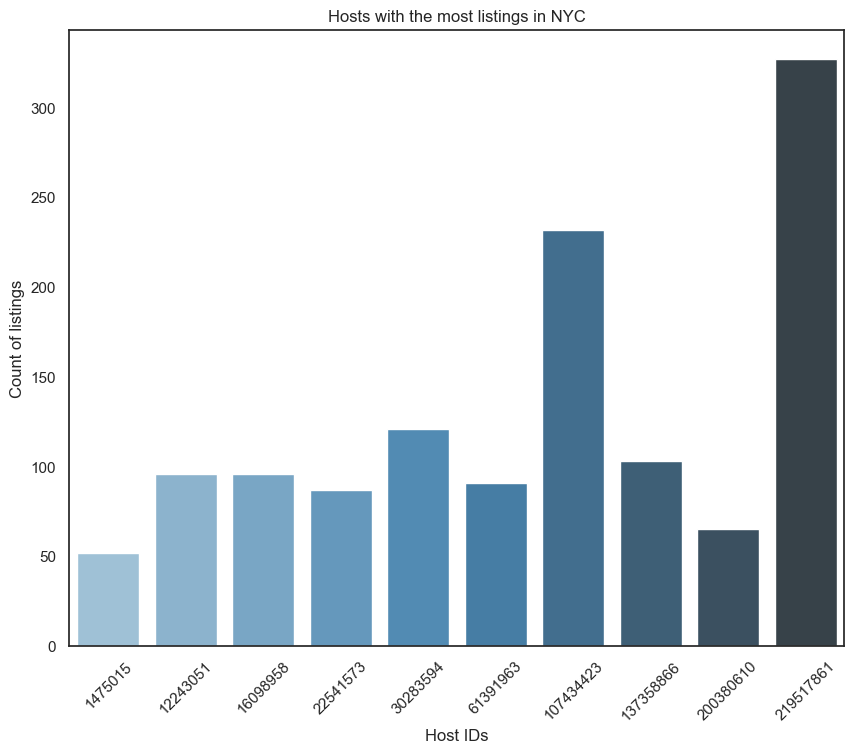

In [27]:
viz_1=sns.barplot(x="P_Count", y="count", data=top_10_hosts,
                 palette='Blues_d')
viz_1.set_title('Hosts with the most listings in NYC')
viz_1.set_ylabel('Count of listings')
viz_1.set_xlabel('Host IDs')
viz_1.set_xticklabels(viz_1.get_xticklabels(), rotation=45)

There are 37457 unique host_ids

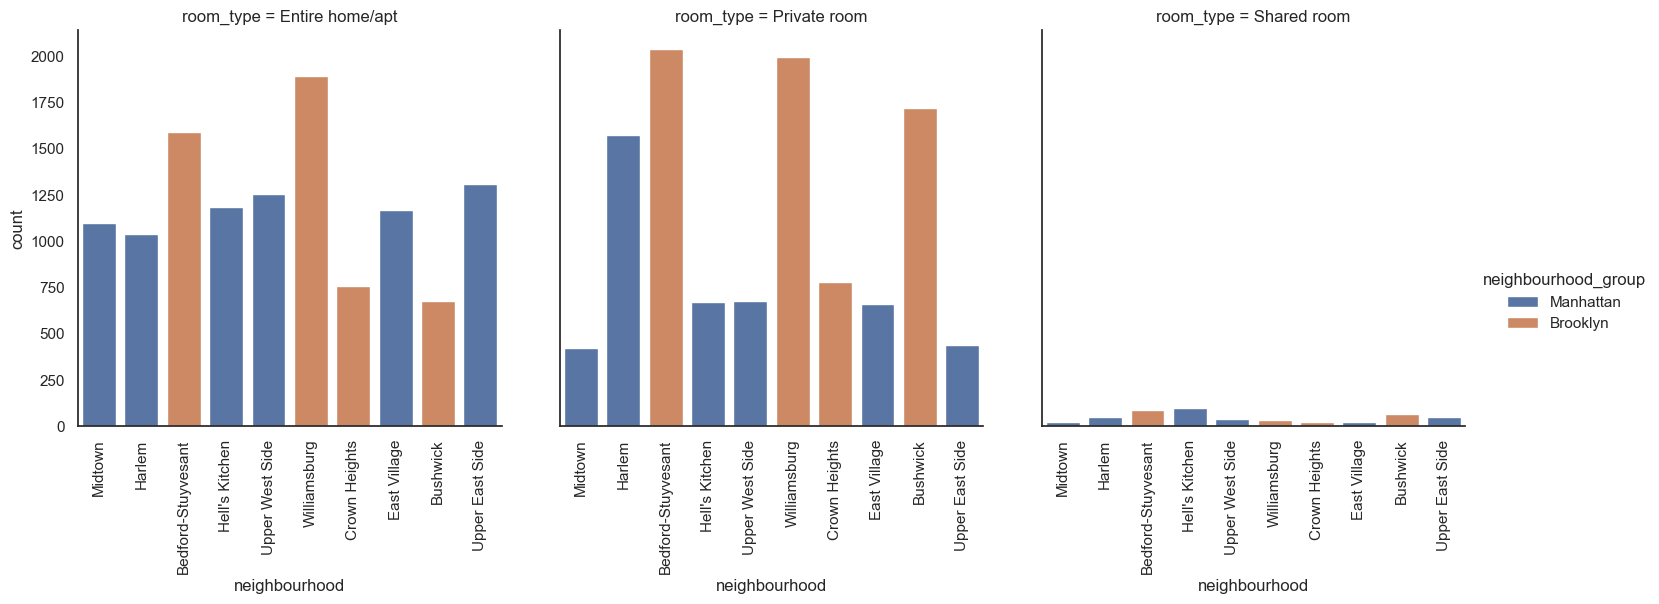

In [28]:
sub_7=df.loc[df['neighbourhood'].isin(['Williamsburg','Bedford-Stuyvesant','Harlem','Bushwick',
                 'Upper West Side','Hell\'s Kitchen','East Village','Upper East Side','Crown Heights','Midtown'])]
#using catplot to represent multiple interesting attributes together and a count
viz_2=sns.catplot(x='neighbourhood', hue='neighbourhood_group', col='room_type', data=sub_7, kind='count')
viz_2.set_xticklabels(rotation=90)

The observation that is definitely contrasted the most is that 'Shared room' type Airbnb listing is barely available among 10 most listing-populated neighborhoods. Then, we can see that for these 10 neighborhoods only 2 boroughs are represented: Manhattan and Brooklyn; that was somewhat expected as Manhattan and Brooklyn are one of the most traveled destinations, therefore would have the most listing availability. We can also observe that Bedford-Stuyvesant and Williamsburg are the most popular for Manhattan borough, and Harlem for Brooklyn.

The feature importance analysis revealed that the property_type_private_room in rental unit, bedrooms, longitude, and minimum nights were the most important indicators of Airbnb listing prices.

Text(0.5, 1.0, 'Density and distribution of prices for each neighbourhood_group')

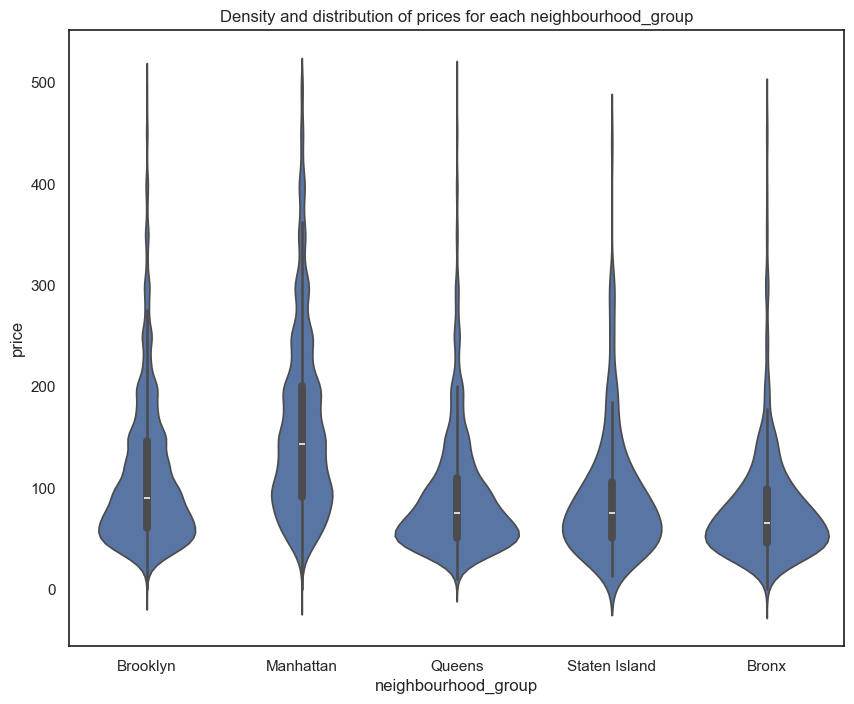

In [29]:
#remove extreme values for better visualization
sub_6=df[df.price < 500]
#using violinplot to showcase density and distribtuion of prices 
viz_3=sns.violinplot(data=sub_6, x='neighbourhood_group', y='price')
viz_3.set_title('Density and distribution of prices for each neighbourhood_group')

Manhattan has the highest range of prices for the listings with 150 dollar price as average observation followed by Brooklyn with 90 per night. 
Queens and Staten Island appear to have very similar distributions.
Bronx is the cheapest of them all. 
This distribution and density of prices were completely expected as:
Manhattan is one of the most expensive places in the world to live in 
Bronx on other hand appears to have lower standards of living.

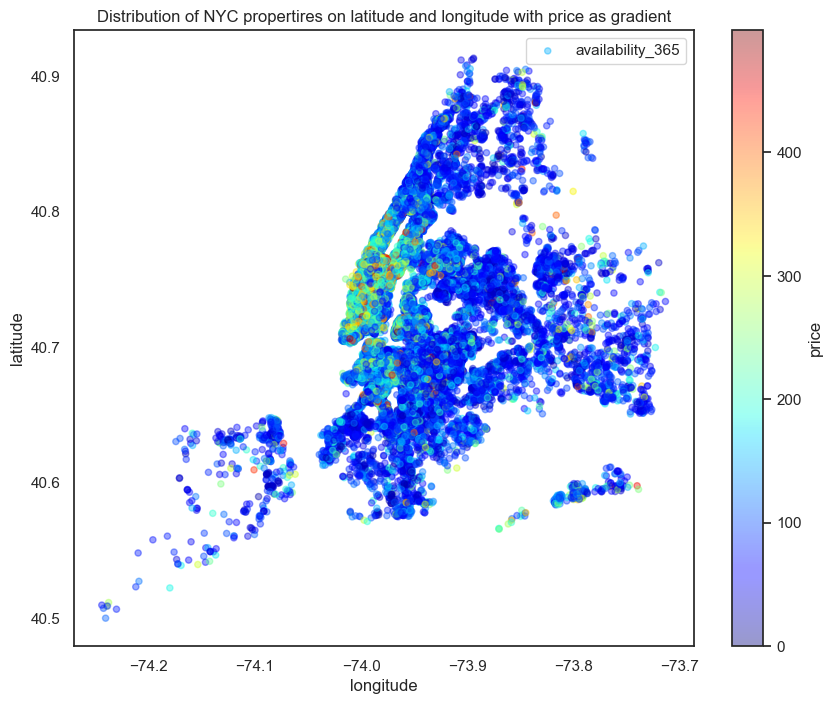

In [30]:
#Using longtitude and latitude columns
viz_4=sub_6.plot(kind='scatter', x='longitude', y='latitude', label='availability_365', c='price',
                  cmap=plt.get_cmap('jet'), colorbar=True, alpha=0.4, figsize=(10,8))
viz_4.set_title('Distribution of NYC propertires on latitude and longitude with price as gradient')
viz_4.legend()

This distribution provides us some insight but without overlaying it on the NYC map with the given latitude and longitude we can actually see the NYC housing patterns across the city as well as find out the neighbourhood-specific trends.

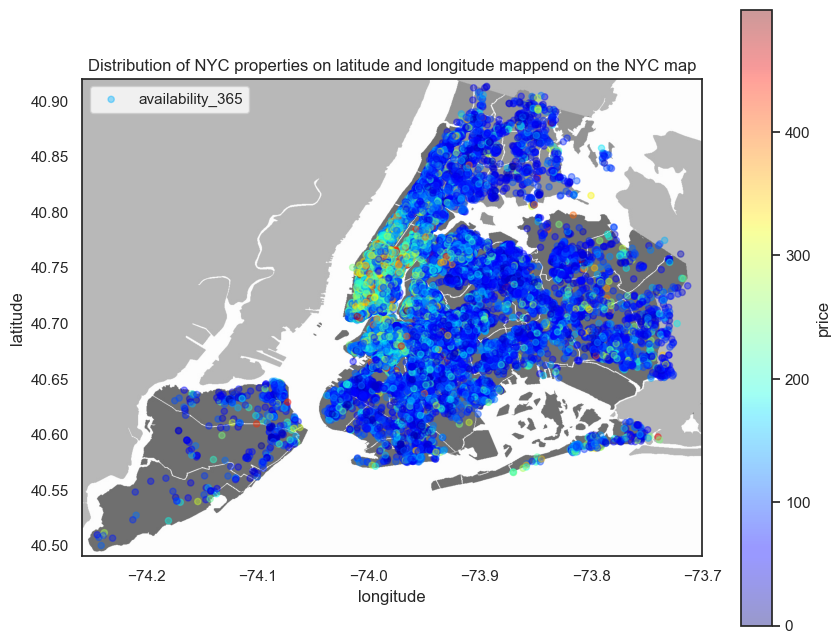

In [31]:
import os
import matplotlib.image as mpimg
plt.figure(figsize=(10,8))
file_path = os.path.join(os.getcwd(), 'airbnb-data/nyc.jpg')

img = mpimg.imread(file_path)
#scaling the image based on the latitude and longitude max and mins for proper output
plt.imshow(img,zorder=0,extent=[-74.258, -73.7, 40.49,40.92])
ax=plt.gca()
#using scatterplot again
sub_6.plot(kind='scatter', x='longitude', y='latitude', label='availability_365', c='price', ax=ax, 
           cmap=plt.get_cmap('jet'), colorbar=True, alpha=0.4, zorder=5)

plt.legend()
plt.title("Distribution of NYC properties on latitude and longitude mappend on the NYC map")
plt.show()

We observe that we end up with a very immersive heatmap. Using latitude and longitude points were able to visualize all NYC listings. Also, we added a color-coded range for each point on the map based on the price of the listing.

Text(0.5, 1.0, 'Room Type vs Price vs Neighbourhood Group')

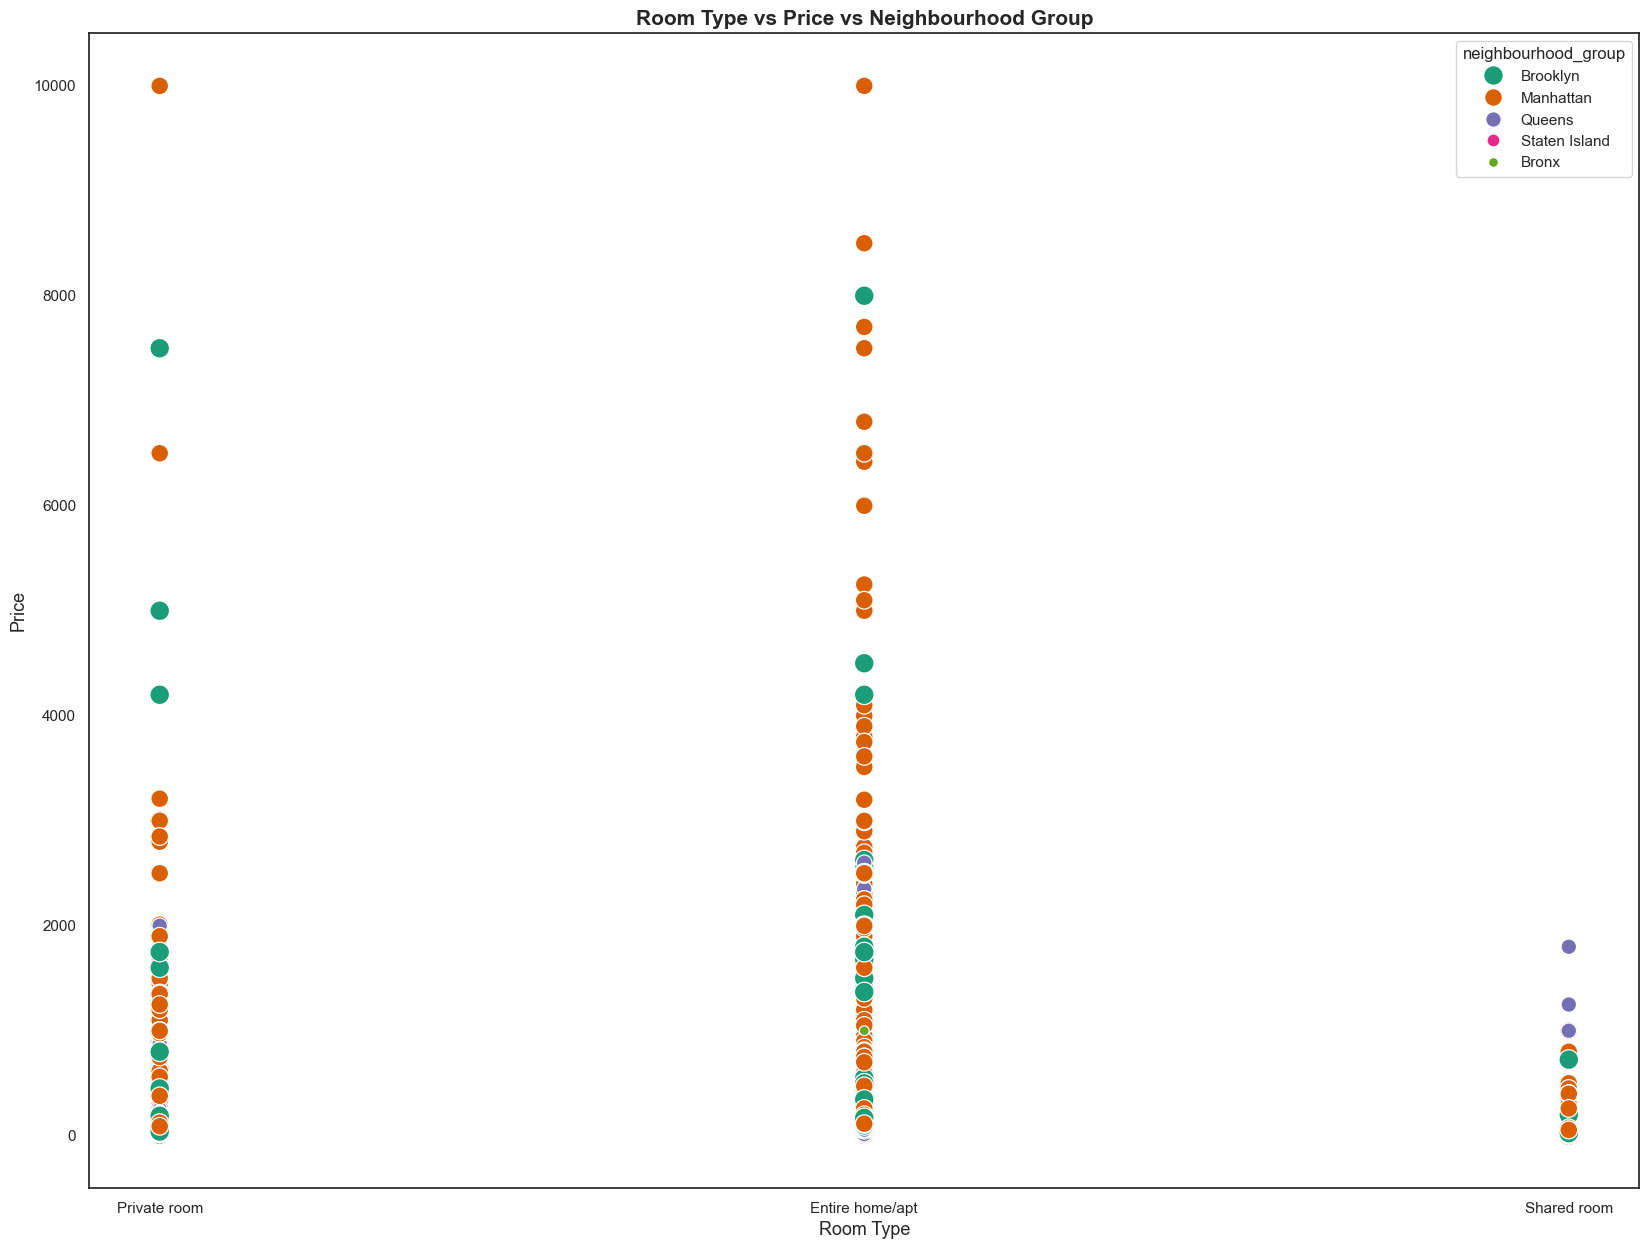

In [32]:
plt.figure(figsize=(20,15))
sns.scatterplot(x="room_type", y="price",
            hue="neighbourhood_group", size="neighbourhood_group",
            sizes=(50, 200), palette="Dark2", data=df)

plt.xlabel("Room Type", size=13)
plt.ylabel("Price", size=13)
plt.title("Room Type vs Price vs Neighbourhood Group",size=15, weight='bold')

Shared rooms as expected are the cheapest option
Entire home/apt also as expected has the highest density of high-price listings
Primate rooms have a disctibution somewhere in between the two

# INTERPRETATION

This Airbnb ('AB_NYC_2019') dataset for the 2019 year appeared to be a very rich dataset with a variety of columns that allowed us to do deep data exploration on each significant column presented. 

## ANALYSIS
First, we have found hosts that take good advantage of the Airbnb platform and provide the most listings; we found that our top host has 327 listings. After that, we proceeded with analyzing boroughs and neighborhood listing densities and what areas were more popular than another. Next, we put good use of our latitude and longitude columns and used to create a geographical heatmap color-coded by the price of listings. Further, we came back to the first column with name strings and had to do a bit more coding to parse each title and analyze existing trends on how listings are named as well as what was the count for the most used words by hosts. Lastly, we found the most reviewed listings and analyzed some additional attributes. 

## INSIGHTS & PATTERNS
Please refer to the various insights and trends first in the EDA and the in the data visualizations sections. The final insights are listed in the [Project Report](https://github.com/akhil9650/Udacity-Capstone-Masters-in-AI/blob/updates/AI%20Programming%20Foundations%20Project/AI%20Programming%20Foundations%20Project%20(1).pdf)

## LIMITATIONS & ASSUMPTIONS
1. Assume all data is correct and free of reporting errors
2. The trends may be seasonal
3. The trends may be AIRBNB specific and may not apply in certain cases to the NYC housing market in general
4. Many listings may be duplicate or inactivate for too long of a time to have a meaningful impact but we can't gauge that with the dataset.

## DATA CLEANIING & BIAS
While we try to be as objective as possible in picking the right columns to work on in the dataset, and what to remove, bias can still be present and the results or insights derived may vary for every person. 

Missing data can cause problems in the analysis, such as biased results, incorrect statistical inferences, and errors in machine learning models. By identifying missing data, we handled it by dropping the rows with missing values. Another option here can be by imputing the missing values 

Outliers are data points that are significantly different from other data points in a dataset. They can be much larger or much smaller than the other data points in the dataset and can distort the overall analysis of the data. We see this in the 'Room Type vs Price vs Neighbourhood Group' visualization above, where certain extremely high 'Private Room' and 'Entire Home/Apt' price values are pushing the average cost for these categories up, hence increasing bias. For ML training models, these outliers should be removed from the final datasets. Refer to the 'DATA CLEANING: OUTLIERS' section for another alternative. 

## FUTURE SCOPE
For Airbnb listing price prediction, the feature importance analysis can help identify which features have the most significant impact on the price of a listing, such as minimum nights required, the number of reviews, and the host response rate.
This information can be used by property hosts to make informed decisions about pricing their listings, and by Airbnb to make recommendations to hosts to improve the quality of their listings to attract more bookings. Additionally, feature importance can help identify which features have less impact on the outcome variable, and therefore can be excluded from the model to simplify it and reduce the computation required for predictions.

Please note the following for data modeling and model training on this data: Transforming variables involved standardizing and scaling numerical variables as well as encoding categorical input variables using one-hot encoding. This is to be done to ensure that all numerical variables are in the same range to avoid bias toward higher-valued variables and to convert categorical variables into a format that can be used for modeling purposes.

## CONCLUSION
Overall, we discovered a very good number of interesting relationships between features and explained each step of the process. This data analytics is very much mimicked on a higher level on Airbnb Data/Machine Learning team for better business decisions, control over the platform, marketing initiatives, implementation of new features and much more. Therefore, I hope this kernel helps everyone!